## CTG Classification using Pre-Trained ResNet-50 Model

This notebook trains a ResNet-50 model on the CWT spectrograms generated from fetal heart rate signals.
The spectrograms are pre-organized into train/validation/test sets and class folders (normal/distressed).

In [2]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    auc
)
import json

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

c:\Users\ZEYNEP\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [8]:
class Config:
    '''
    Configuration class for dataset paths and training parameters.
    '''

    output_folder = 'outputs/spectograms'
    train = os.path.join(output_folder, 'train')
    validation = os.path.join(output_folder, 'validation')
    test = os.path.join(output_folder, 'test')

    #Model Params
    IMG_SIZE = (224, 224)
    BATCH_SIZE = 32
    Epochs = 50
    LR = 1e-4
    PATIENCE = 5

    #Data Augmentation Params
    ROTATION_RANGE = 20
    WIDTH_SHIFT_RANGE = 0.2
    HEIGHT_SHIFT_RANGE = 0.2
    SHEAR_RANGE = 0.2
    ZOOM_RANGE = 0.2
    HORIZONTAL_FLIP = True
    FILL_MODE = 'nearest'
    
    # Model architecture
    DENSE_UNITS = [256, 128]
    DROPOUT_RATES = [0.5, 0.3]
    L2_REGULARIZATION = 0.01
    
    # Training
    EARLY_STOPPING_PATIENCE = 10
    REDUCE_LR_PATIENCE = 5
    MIN_LR = 1e-7

config = Config()

### Load Datasets
This section loads image datasets from the prebuilt directories (`train`, `validation`, `test`).
Data loading is done with augmentation

In [7]:
def create_data_pipelines():
    """Create data pipelines with augmentation for training and without for validation/test"""
    
    # Training data with augmentation
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=config.ROTATION_RANGE,
        width_shift_range=config.WIDTH_SHIFT_RANGE,
        height_shift_range=config.HEIGHT_SHIFT_RANGE,
        shear_range=config.SHEAR_RANGE,
        zoom_range=config.ZOOM_RANGE,
        horizontal_flip=config.HORIZONTAL_FLIP,
        fill_mode=config.FILL_MODE
    )
    
    # Validation/Test data (no augmentation)
    val_test_datagen = ImageDataGenerator(rescale=1./255)
    
    # Create generators
    train_generator = train_datagen.flow_from_directory(
        config.train,
        target_size=config.IMG_SIZE,
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=True,
        seed=42
    )
    
    validation_generator = val_test_datagen.flow_from_directory(
        config.validation,
        target_size=config.IMG_SIZE,
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    
    test_generator = val_test_datagen.flow_from_directory(
        config.test,
        target_size=config.IMG_SIZE,
        batch_size=config.BATCH_SIZE,
        class_mode='binary',
        shuffle=False
    )
    
    # Print dataset statistics
    print("=" * 60)
    print("DATASET STATISTICS:")
    print(f"Training samples: {train_generator.samples}")
    print(f"Validation samples: {validation_generator.samples}")
    print(f"Test samples: {test_generator.samples}")
    print(f"Class indices: {train_generator.class_indices}")
    print("=" * 60)
    
    return train_generator, validation_generator, test_generator

In [9]:
train_generator, validation_generator, test_generator = create_data_pipelines()

Found 748 images belonging to 2 classes.
Found 51 images belonging to 2 classes.
Found 56 images belonging to 2 classes.
DATASET STATISTICS:
Training samples: 748
Validation samples: 51
Test samples: 56
Class indices: {'class_0_normal': 0, 'class_1_distressed': 1}


In [79]:
'''
from tensorflow.keras.applications.resnet50 import preprocess_input

def preprocess(x, y):
    return preprocess_input(x), y

train_ds = train_dataset.map(preprocess)
val_ds   = validation_dataset.map(preprocess)
test_ds  = test_dataset.map(preprocess)

train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.prefetch(tf.data.AUTOTUNE)
'''


'\nfrom tensorflow.keras.applications.resnet50 import preprocess_input\n\ndef preprocess(x, y):\n    return preprocess_input(x), y\n\ntrain_ds = train_dataset.map(preprocess)\nval_ds   = validation_dataset.map(preprocess)\ntest_ds  = test_dataset.map(preprocess)\n\ntrain_ds = train_ds.prefetch(tf.data.AUTOTUNE)\nval_ds   = val_ds.prefetch(tf.data.AUTOTUNE)\ntest_ds  = test_ds.prefetch(tf.data.AUTOTUNE)\n'

In [80]:
'''
labels = []

for _, y in train_dataset:
    y = y.numpy().reshape(-1)   # FLATTEN batch
    labels.append(y)

y_train = np.concatenate(labels).astype(int)

print("Unique labels:", np.unique(y_train, return_counts=True))
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=y_train
)


class_weight = {
    0: class_weights_array[0],
    1: class_weights_array[1]
}


class_weight = {0: 1.0, 1: 3.0}

print("Class weights:", class_weight)
'''

'\nlabels = []\n\nfor _, y in train_dataset:\n    y = y.numpy().reshape(-1)   # FLATTEN batch\n    labels.append(y)\n\ny_train = np.concatenate(labels).astype(int)\n\nprint("Unique labels:", np.unique(y_train, return_counts=True))\nclass_weights_array = compute_class_weight(\n    class_weight="balanced",\n    classes=np.array([0, 1]),\n    y=y_train\n)\n\n\nclass_weight = {\n    0: class_weights_array[0],\n    1: class_weights_array[1]\n}\n\n\nclass_weight = {0: 1.0, 1: 3.0}\n\nprint("Class weights:", class_weight)\n'

In [10]:
# Calculate actual validation distribution
val_classes = validation_generator.classes
n_normal = np.sum(val_classes == 0)
n_distressed = np.sum(val_classes == 1)

print(f"\nValidation Distribution:")
print(f"Normal: {n_normal} ({n_normal/len(val_classes)*100:.1f}%)")
print(f"Distressed: {n_distressed} ({n_distressed/len(val_classes)*100:.1f}%)")



Validation Distribution:
Normal: 39 (76.5%)
Distressed: 12 (23.5%)


In [96]:
''' 
Build ResNet-50 Model 
include_top = False means we don't include the final dense layer.
Which allows us to add our own custom layers on top of the base model.
'''
def build_daydulo_resnet50():
    ''' 
    Builds a ResNet-50 model for binary classification following Daydulo's approach.
    '''
    # Load pre-trained ResNet-50
    base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
    )
    
    # Freeze all but last 10 layers
    for layer in base_model.layers[:-10]:
        layer.trainable = False
    for layer in base_model.layers[-10:]:
        layer.trainable = True
    
    print(f"Trainable layers: {sum([1 for l in base_model.layers if l.trainable])}")

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    
    # Larger network head
    x = Dense(512, activation='relu', kernel_initializer='he_normal')(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu', kernel_initializer='he_normal')(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu', kernel_initializer='he_normal')(x)
    x = Dropout(0.3)(x)

    # Output with proper bias
    initial_bias = np.log(n_distressed / n_normal)
    output = Dense(
        1, 
        activation='sigmoid',
        bias_initializer=tf.keras.initializers.Constant(initial_bias),
        name='output'
    )(x)

    return Model(inputs=base_model.input, outputs=output)


In [97]:
# Build and compile the model
daydulo_resnet50 = build_daydulo_resnet50()
#daydulo_resnet50.summary()

Trainable layers: 10


### Model Architecture

Input (224 × 224 × 3)

→ ResNet-50 Backbone (Frozen except last 10 layers)

→ GlobalAveragePooling2D

→ BatchNormalization

→ Dense (512, ReLU, He init)

→ Dropout (0.5)

→ Dense (256, ReLU, He init)

→ Dropout (0.4)

→ Dense (128, ReLU, He init)

→ Dropout (0.3)

→ Dense (1, Sigmoid, bias initialised)


https://github.com/birth-outcomes/ctg_exploratory/blob/main/09_daydulo_resnet50.ipynb -> they a series of model versions for this task, and explored whether the training and validation curved followed each other or had overfitting. 

They then compared different results. The evaluation showed thet the addition dropout layers reduced overfitting. 

I, then found out, this model architecture is especially helpful for clinical tasks is it forces abstraction, while reducing overfitting and allowing the model learn complex patterns. 

## Summary of Results

| Model layers (additional to ResNet50 and final classification layer) | Epochs | Output |
|--------------------------------------------------------------------|--------|--------|
| None | 40 | Overfitting |
| Dropout | 40 | Not overfitting |
| Dropout + Dense 1000 | 40 | Not overfitting |
| Dropout + Dense 1000 + Dropout | 40 | Not overfitting |
| Dense 1000 + Dropout | 150 | Overfitting |
| Dense 1000 | 40 | Overfitting |
| Dense 100 + Dropout + Dense 100 + Dropout | 150 | Accuracy plateaus after ~20 epochs while loss increases |
| Dropout + Dense 1000 + Dropout | 200 | Overfitting |

**Table 1** Summary of architectural experiments conducted using a ResNet50 backbone. Full implementation and training logs are available in the experiment notebook.

Source:  
[09_daydulo_resnet50.ipynb](https://github.com/birth-outcomes/ctg_exploratory/blob/main/09_daydulo_resnet50.ipynb)


In [84]:
'''
Model Architecture = Dropout -> Dense(100, relu) -> Dropout -> Dense(100, relu) -> Dropout -> Dense(1, sigmoid)
This architecture helps in reducing overfitting and allows the model to learn complex patterns.
This architecture also forces abstraction which is important for medical tasks. 


x = layers.Dropout(0.5)(x)
x = layers.Dense(100, activation="relu")(x)
x = layers.Dropout(0.5)(x)

output = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=base_model.input, outputs=output)
'''

'\nModel Architecture = Dropout -> Dense(100, relu) -> Dropout -> Dense(100, relu) -> Dropout -> Dense(1, sigmoid)\nThis architecture helps in reducing overfitting and allows the model to learn complex patterns.\nThis architecture also forces abstraction which is important for medical tasks. \n\n\nx = layers.Dropout(0.5)(x)\nx = layers.Dense(100, activation="relu")(x)\nx = layers.Dropout(0.5)(x)\n\noutput = layers.Dense(1, activation="sigmoid")(x)\n\nmodel = tf.keras.Model(inputs=base_model.input, outputs=output)\n'

In [98]:
'''
Compile the model
Loss calculated according to the MATLAB deep learning documantation. 
It states that if the final layer of a network is a classification layer, the lass function  is cross-entropy loss. 
'''

daydulo_resnet50.compile(
    optimizer=Adam(learning_rate= 5e-5),
    loss= "binary_crossentropy",
    metrics=[
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.BinaryAccuracy(name="accuracy")
    ]
)



In [99]:
# Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",  # AUC is better for imbalanced data
        mode="max",
        patience=10,  # Increased patience
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=config.MIN_LR,
        verbose=1
    )
]



### Training the Model
As stated in daydulo et. al. They used: 

1- Validation frequency set is 15 iterations 

2- Validation frequency 20 iterations 

3- Approximately 800 iterations in total. 

In deep learning, the smallest unit of work is: 

forward pass + loss + backward pass + weight update

and 1 iteration is 1 batch. In 1 batch loss is computed, gradients backpropagated and weights updated once. Normally, Keras controls this, however, we override it to have the number of updates and comparable experiments controlled. 

Why validate every 20 iterations?

If we validate too often, training slows down and GPU/CPU gets wasted. However, if we validate to rarely, we might miss the signs of overfitting and we would have bad checkpoints. 20 is good trade off because it is frequent enough to monitor learning and spotting overfitting. Also, it is not so frequent which might kill the performance. 

Source: daydulo et. al.

In this model, the additional training characteristics are as follows: 

1- Partial fine-tuning: to improve domain adaptation 
2- Progressive dropout: to stabilise training 
3- Bias initialisation: To address class imbalance 

the aim is to produce more calibrated and transferable probabilities. 

In [100]:
''' 
Training 
1 iteration = 1 batch 
20 × 40 = 800 iterations
Keras does not support validation every N batches natively,so I simulate it using a custom callback
'''
validation_freq_steps = 20


In [101]:
'''
Train the model
'''
history = daydulo_resnet50.fit(
    train_generator,  
    validation_data=validation_generator,
    epochs=config.Epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 24s 766ms/step - accuracy: 0.4786 - auc: 0.5313 - loss: 1.7207 - precision: 0.5795 - recall: 0.1262 - val_accuracy: 0.7647 - val_auc: 0.5011 - val_loss: 0.5905 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-05
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 747ms/step - accuracy: 0.5281 - auc: 0.5458 - loss: 1.0356 - precision: 0.5921 - recall: 0.4059 - val_accuracy: 0.7647 - val_auc: 0.4647 - val_loss: 0.5471 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-05
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 788ms/step - accuracy: 0.5481 - auc: 0.5600 - loss: 0.9719 - precision: 0.5943 - recall: 0.5149 - val_accuracy: 0.7647 - val_auc: 0.4744 - val_loss: 0.5522 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-05
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 799ms/step - accuracy: 0.5802 - auc: 0.6004 - loss: 0.8950 - precision: 0.6355 - recall: 0.5223 - val_accuracy: 0.7647 - 

### Evaluation 

Parameters: 

AUC (Area Under The Curve): Specifically, this is the AUC of the ROC (Receiver Operating Characteristic) curve. It measures the model's ability to distinguish between classes across all classification thresholds.

Training AUC: How well the model performs on the data it was trained on?

Validation AUC: How well the model performs on unseen data?

Comparing validation and training AUC: the gap between them indicates overfitting. If training AUC keeps rising but validation AUC plateaus/declines, the model is memorizing training data rather than learning generalizable patterns.

Note: AUC is important for medical tasks (AUC vs Accuracy): Because the medical dataset is imbalanced, a dummy model that predicts normal for everything will have a high accuracy on a dataset where the normal data is much higher than abnormal data (like our CTG dataset). This would be misleading to only look at accuracy. That is why we evaluate on AUC and AUC evaluates performance across all possible thresholds. Measures how well the model ranks positive cases higher than negative cases. 

#### Accuracy vs AUC Comparison

| Aspect | Accuracy | AUC |
|------|----------|-----|
| **Class Imbalance** | Misleading | Robust |
| **Decision Threshold** | Fixed | Shows all thresholds |
| **Clinical Utility** | Poor | Excellent |
| **Interpretation** | “How often right?” | “How well separates sick from healthy?” |


In [102]:
'''
Evaluation on Validation Set
Validation set is used during training to monitor model performance and tune hyperparameters.
Validation set is also used for the early stopping and threshold selection 
'''
# Get predictions on validation set
val_predictions = daydulo_resnet50.predict(validation_generator)
val_true = validation_generator.classes

# Calculate AUC
val_auc = roc_auc_score(val_true, val_predictions)
print(f"Validation AUC: {val_auc:.4f}")


#calculate accuracy 
val_acc = tf.keras.metrics.BinaryAccuracy()
val_acc.update_state(val_true, val_predictions)
print(f"Validation Accuracy: {val_acc.result().numpy():.4f}")

1/2 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x00000166A3CA4E00> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step
Validation AUC: 0.7436
Validation Accuracy: 0.7059


In [103]:
'''
Find optimal threshold 
threshold is chosen to maximize the difference between TPR and FPR.
In our dataset, the optimal threshold is found to be around 0.3, indicating that the model is more sensitive to detecting the positive class (distressed fetuses) at this threshold.
Note that the threshold here is probabilistic, meaning that if the model's output probability for a sample is above this threshold, it is classified as positive (distressed), otherwise negative (normal).
'''
fpr, tpr, thresholds = roc_curve(val_true, val_predictions)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold: {optimal_threshold:.4f}")


Optimal threshold: 0.3950


In [104]:
''' 
Evaluate with different thresholds
This will help us understand how different threshold settings impact model performance.
'''
print("THRESHOLD ANALYSIS")

for thresh in [0.3, 0.35, 0.4, optimal_threshold, 0.5]:
    val_pred_classes = (val_predictions > thresh).astype(int).flatten()
    
    if val_pred_classes.sum() > 0:
        print(f"\n--- Threshold: {thresh:.4f} ---")
        print(classification_report(val_true, val_pred_classes, 
                                   target_names=['Normal', 'Distressed'],
                                   digits=4))
        cm = confusion_matrix(val_true, val_pred_classes)
        print(f"Confusion Matrix:")
        print(f"  TN={cm[0,0]}, FP={cm[0,1]}")
        print(f"  FN={cm[1,0]}, TP={cm[1,1]}")

THRESHOLD ANALYSIS

--- Threshold: 0.3000 ---
              precision    recall  f1-score   support

      Normal     1.0000    0.1795    0.3043        39
  Distressed     0.2727    1.0000    0.4286        12

    accuracy                         0.3725        51
   macro avg     0.6364    0.5897    0.3665        51
weighted avg     0.8289    0.3725    0.3336        51

Confusion Matrix:
  TN=7, FP=32
  FN=0, TP=12

--- Threshold: 0.3500 ---
              precision    recall  f1-score   support

      Normal     0.9167    0.5641    0.6984        39
  Distressed     0.3704    0.8333    0.5128        12

    accuracy                         0.6275        51
   macro avg     0.6435    0.6987    0.6056        51
weighted avg     0.7881    0.6275    0.6547        51

Confusion Matrix:
  TN=22, FP=17
  FN=2, TP=10

--- Threshold: 0.4000 ---
              precision    recall  f1-score   support

      Normal     0.8529    0.7436    0.7945        39
  Distressed     0.4118    0.5833    0.4828 

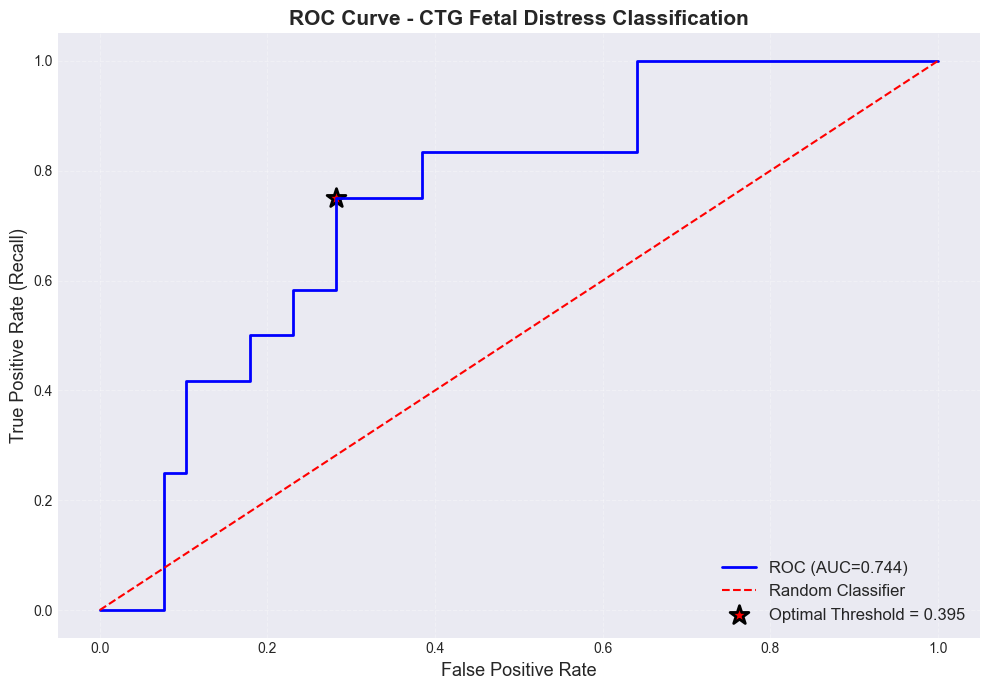

In [105]:
'''
Plot ROC (Receiver Operating Characteristic) curve
This will help visualize the trade-off between sensitivity (TPR) and specificity (1-FPR) at various threshold settings.
'''
plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC (AUC={val_auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Classifier')
plt.scatter(fpr[optimal_idx], tpr[optimal_idx], s=200, c='red', marker='*',
           edgecolors='black', linewidths=2,
           label=f'Optimal Threshold = {optimal_threshold:.3f}')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate (Recall)', fontsize=13)
plt.title('ROC Curve - CTG Fetal Distress Classification', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc='lower right')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('ctg_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

### Evaluatiopn on Test Set

In [106]:
'''
Evaluate on test set
this will help us understand how well the model generalizes to unseen data.
we use the optimal threshold determined from the validation set to classify test samples.
'''
print("TEST SET EVALUATION")

test_predictions = daydulo_resnet50.predict(test_generator)
test_true = test_generator.classes
test_auc = roc_auc_score(test_true, test_predictions)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test Accuracy: {test_predictions}")

test_pred_classes = (test_predictions > optimal_threshold).astype(int).flatten()
print(f"\nResults with optimal threshold ({optimal_threshold:.4f}):")
print(classification_report(test_true, test_pred_classes,
                           target_names=['Normal', 'Distressed'],
                           digits=4))
print(f"\nConfusion Matrix:")
print(confusion_matrix(test_true, test_pred_classes))

TEST SET EVALUATION
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 435ms/step
Test AUC: 0.6440
Test Accuracy: [[0.34118766]
 [0.3928336 ]
 [0.2031333 ]
 [0.51795566]
 [0.4137417 ]
 [0.46614596]
 [0.26042703]
 [0.30586317]
 [0.3146567 ]
 [0.3598025 ]
 [0.3712228 ]
 [0.35595334]
 [0.24607895]
 [0.30078298]
 [0.2857165 ]
 [0.32927436]
 [0.29982805]
 [0.27882156]
 [0.42196172]
 [0.3531263 ]
 [0.45668194]
 [0.23918812]
 [0.43274334]
 [0.34333616]
 [0.2886569 ]
 [0.32843757]
 [0.32894546]
 [0.25058872]
 [0.42511407]
 [0.39875725]
 [0.33364782]
 [0.3568323 ]
 [0.28196982]
 [0.48524883]
 [0.42682642]
 [0.3786215 ]
 [0.27770165]
 [0.30689335]
 [0.42432547]
 [0.3044516 ]
 [0.33762088]
 [0.2798884 ]
 [0.38583493]
 [0.3954403 ]
 [0.38922295]
 [0.3827483 ]
 [0.24754697]
 [0.35792214]
 [0.364537  ]
 [0.37071866]
 [0.3737523 ]
 [0.40445566]
 [0.29184943]
 [0.43951473]
 [0.41695794]
 [0.42418233]]

Results with optimal threshold (0.3950):
              precision    recall  f1-score   support

      Normal     0.8000    

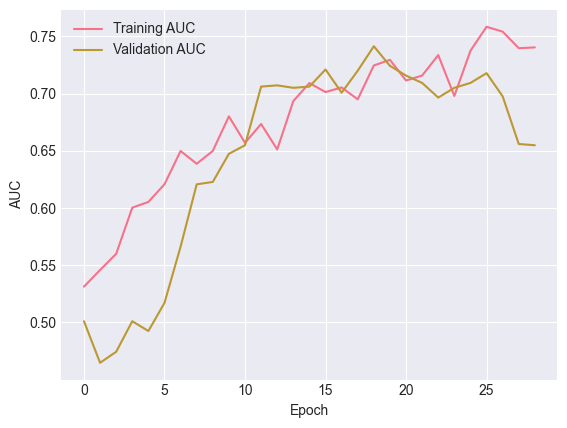

In [107]:
'''
Plot training & validation AUC values
'''

plt.plot(history.history['auc'], label='Training AUC')
plt.plot(history.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.grid(True)
plt.show()


### Evaluation of results: 


## Threshold Comparison Summary

| Threshold | Accuracy | Distressed Precision | Distressed Recall | Distressed F1 | TN | FP | FN | TP | Key Behaviour |
|----------|----------|----------------------|-------------------|---------------|----|----|----|----|--------------|
| **0.30** | 0.373 | 0.273 | **1.000** | 0.429 | 7 | 32 | 0 | 12 | Catches *all* distressed cases, many false alarms |
| **0.35** | 0.628 | 0.370 | 0.833 | **0.513** | 22 | 17 | 2 | 10 | Best balance for distressed detection |
| **0.395** | **0.706** | 0.421 | **0.667** | **0.516** | 28 | 11 | 4 | 8 | Strong balance with fewer false positives |
| **0.40** | **0.706** | 0.412 | 0.583 | 0.483 | 29 | 10 | 5 | 7 | More conservative, misses more distressed |
| **0.50** | **0.706** | 0.000 | 0.000 | 0.000 | 36 | 3 | 12 | 0 | Predicts *no* distressed cases |

### Interpretation

- **Threshold 0.30** prioritizes recall, identifying all distressed cases at the cost of many false positives.
- **Thresholds 0.35–0.395** provide the best trade-off between recall and precision for the distressed class.
- **Threshold 0.50** achieves high accuracy due to class imbalance but fails to detect any distressed cases.

### Recommended Threshold

For safety-critical and medical applications (e.g., CTG analysis), a threshold in the range **0.35–0.395** is recommended, as it minimizes missed distressed cases while maintaining reasonable false positive rates.


### AUC Training vs Validation Curve

The model is learning effectively early on but starts overfitting past epoch 10. The best validation performance is moderate with AUC around 0.69 and 0.70. 

Overall trend: Both training and validation AUC strt low, around 0.55 and rise steadily around epoch then whihc after starts diminishing. 

Overfitting: Gap between training and validation AUC starts widening after the epoch 10. After peaking around epoch 10-15, the validation AUC starts going down while the the training AUC is still improving. This makes the gap between training and validation AUC wider showing a classic overfitting signal. 

Suggestion: Early stopping around epoch 12-15 would likely give the best validation performance. 

### Final perfomance with Best validation auc 

when the AUC is bigger than 0.5, it shows that it is better than random. So the 0.7 validation AUC is considered acceptable but not strong enough for medical tasks. 


### Load the Previous saved model, which performed slightly better compared to other models I have tried. 


In [3]:
# Load your saved model
loaded_model = tf.keras.models.load_model('best_ctg_resnet50_auc_0.81.keras')

In [4]:
print("Model loaded successfully!")
print(f"Model type: {type(loaded_model)}")
loaded_model.summary()

Model loaded successfully!
Model type: <class 'keras.src.models.functional.Functional'>


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 36,175,749 (138.00 MB)

 Trainable params: 5,683,201 (21.68 MB)

 Non-trainable params: 19,126,144 (72.96 MB)

 Optimizer params: 11,366,404 (43.36 MB)

In [18]:
''' 
Evaluation on Validation Set using LOADED model
Validation set is used during training to monitor model performance and tune hyperparameters.
Validation set is also used for the early stopping and threshold selection
This loaded model came from previous evalluations and performaed sligtly better than the other experimental models 
'''

# Use the LOADED model
val_predictions = loaded_model.predict(validation_generator)
val_true = validation_generator.classes

# Calculate AUC
val_auc = roc_auc_score(val_true, val_predictions)
print(f"Validation AUC: {val_auc:.4f}")

# Find optimal threshold
fpr, tpr, thresholds = roc_curve(val_true, val_predictions)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"\nOptimal threshold: {optimal_threshold:.4f}")

# Calculate accuracy 
val_acc = tf.keras.metrics.BinaryAccuracy()
val_acc.update_state(val_true, val_predictions)
print(f"Validation Accuracy: {val_acc.result().numpy():.4f}")

# Calculate AUC on test set
test_predictions = loaded_model.predict(test_generator)
test_true = test_generator.classes
test_auc = roc_auc_score(test_true, test_predictions)
print(f"Test AUC: {test_auc:.4f}")

# Calculate accuracy on test set
test_acc = tf.keras.metrics.BinaryAccuracy()
test_acc.update_state(test_true, test_predictions)  
print(f"Test Accuracy: {test_acc.result().numpy():.4f}")

# Confusion Matrix and Classification Report on test set
test_pred_classes = (test_predictions > optimal_threshold).astype(int).flatten()    
print(f"\nResults with optimal thresholdon test set ({optimal_threshold:.4f}):")
print(classification_report(test_true, test_pred_classes,
                           target_names=['Normal', 'Distressed'],
                           digits=4))   

# Confusion matrix and classification report on validation set
print("THRESHOLD ANALYSIS ON VALIDATION SET")       
for thresh in [0.3, 0.35, 0.4, optimal_threshold, 0.5]:
    val_pred_classes = (val_predictions > thresh).astype(int).flatten()
    
    if val_pred_classes.sum() > 0:
        print(f"\n--- Threshold: {thresh:.4f} ---")
        print(classification_report(val_true, val_pred_classes, 
                                   target_names=['Normal', 'Distressed'],
                                   digits=4))
        cm = confusion_matrix(val_true, val_pred_classes)
        print(f"Confusion Matrix:")
        print(f"  TN={cm[0,0]}, FP={cm[0,1]}")
        print(f"  FN={cm[1,0]}, TP={cm[1,1]}")


2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 597ms/step
Validation AUC: 0.8141

Optimal threshold: 0.2633
Validation Accuracy: 0.7647
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 721ms/step
Test AUC: 0.5975
Test Accuracy: 0.7679

Results with optimal thresholdon test set (0.2633):
              precision    recall  f1-score   support

      Normal     0.8421    0.3721    0.5161        43
  Distressed     0.2703    0.7692    0.4000        13

    accuracy                         0.4643        56
   macro avg     0.5562    0.5707    0.4581        56
weighted avg     0.7094    0.4643    0.4892        56

THRESHOLD ANALYSIS ON VALIDATION SET

--- Threshold: 0.3000 ---
              precision    recall  f1-score   support

      Normal     0.8788    0.7436    0.8056        39
  Distressed     0.4444    0.6667    0.5333        12

    accuracy                         0.7255        51
   macro avg     0.6616    0.7051    0.6694        51
weighted avg     0.7766    0.7255    0.7415        51

Confusion Matrix:
  TN=29, FP=10
 

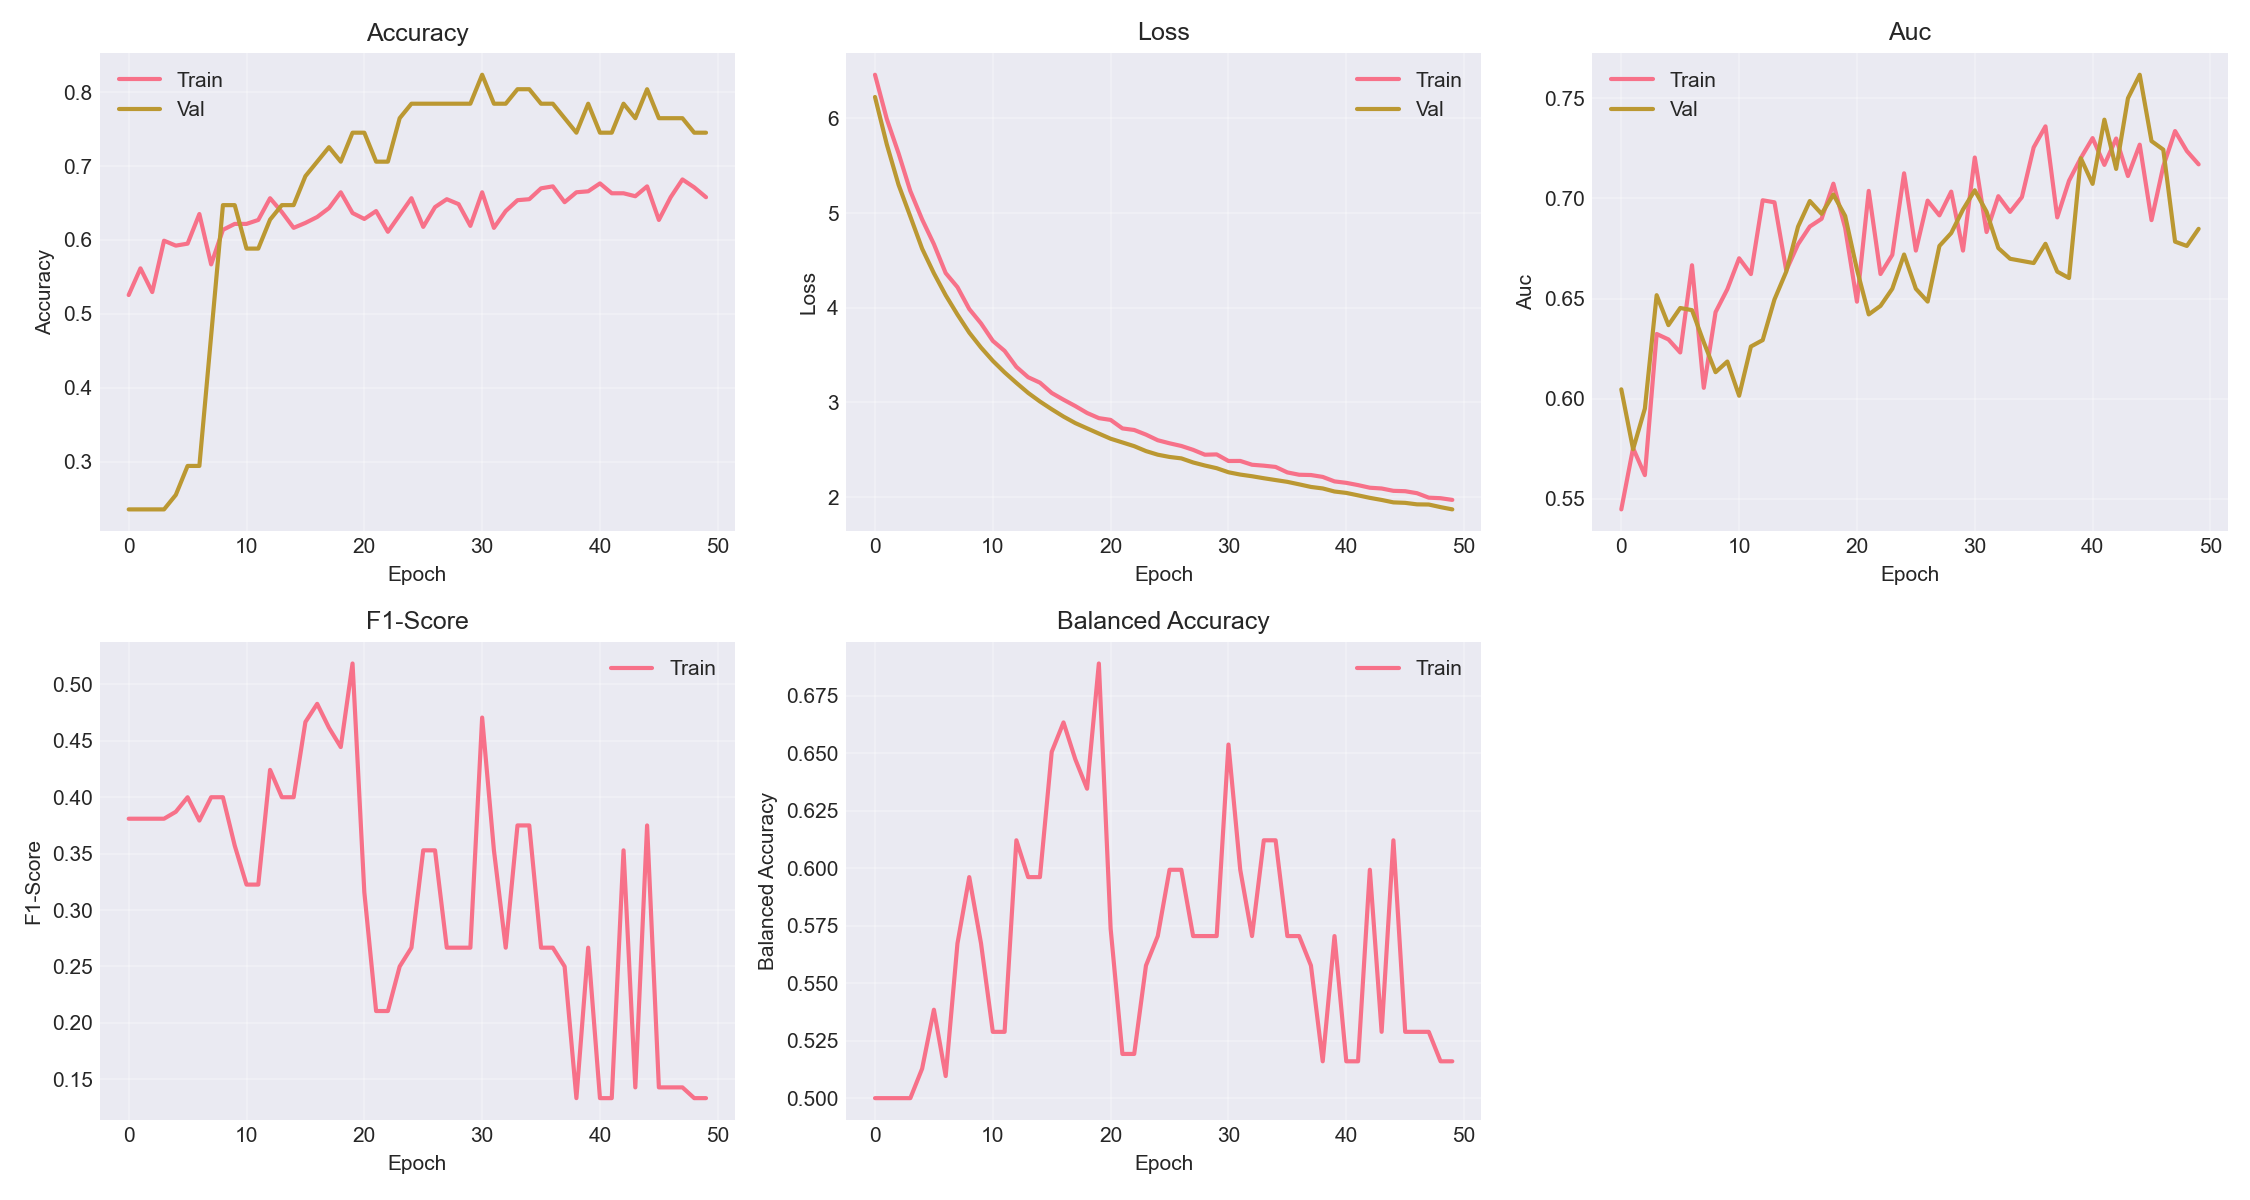

In [21]:
''' 
Load the saved model's training history.png and roc_pr_curves.png from the previous run.
'''
from IPython.display import Image

Image(filename='training_history.png')

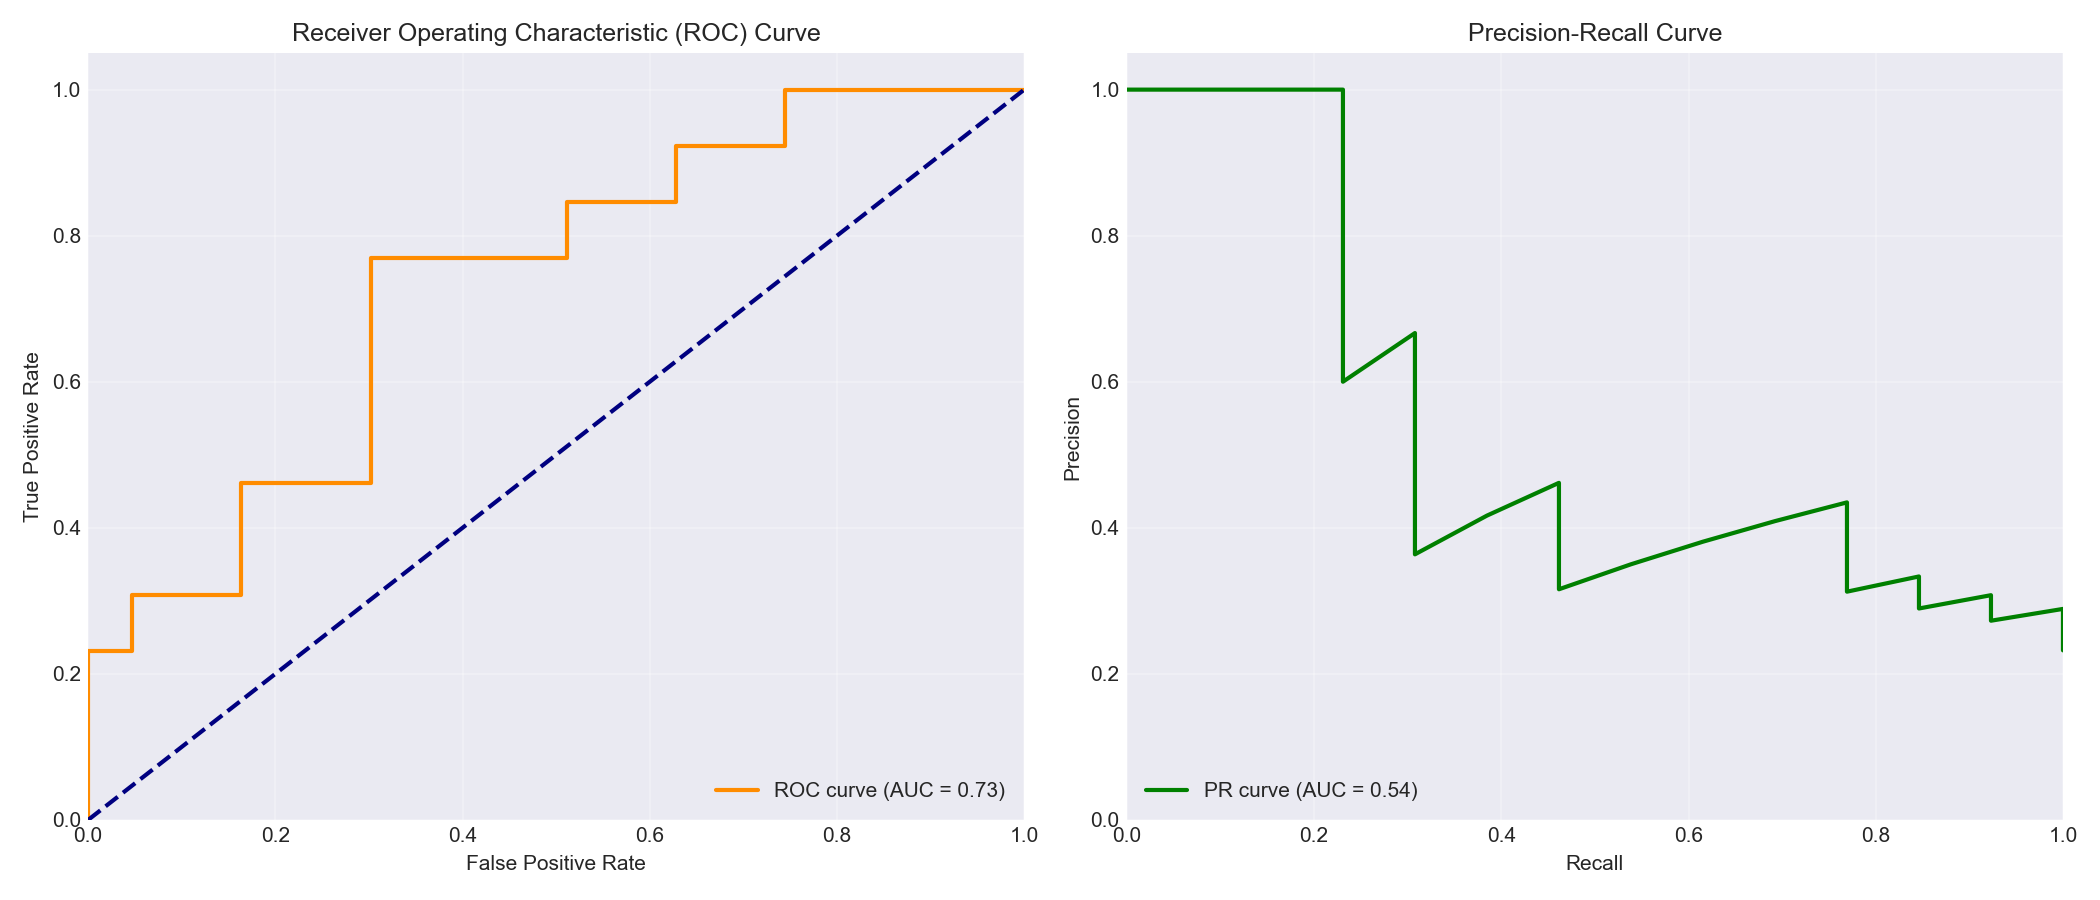

In [23]:
# roc_pr_curves.png
Image(filename='roc_pr_curves.png')

### Evaluation of Results on the Saved Model

Model shows: 

1- Strong Validation AUC: 0.814. This shows excellent separability. 

    At threshold 0.2633:

    Distressed recall: 0.9167

    Normal recall: 0.5385

    Accuracy: 0.6275

These values indicated that model is biased toward detecting Distressed - which I tried making it biased through abnormal class. Because in medical data, we prefer false negatives over false positives to ensure that we are not missing any patients abnormal results. However, optimising recall for Distressed leads to collapse in overall accuracy in this model.

2- Severe Generalisation gap: test AUC drops to 0.598

3- Very sensitive to threshold (sensitivity and recall changes A LOT depending on the threshold)

Test Performance: Test AUC is 0.5975 which indicates the the threshold tuned on validation does NOT transfer to test data. Which shows signs of oveftting to validation distribution. 

Test accuracy at same threshold is 0.4643 and the confusion matrix is:

TN = 21, FP = 18
FN = 1,  TP = 11

which shows an excellent performance for distressed but very high false positive rate, collapsing overall accuracy. 

Overall, the model has strong ranking ability (AUC) but poor generalisation and calibration. 

### Comparison: Saved Model vs The model Above:
## Model Architecture Comparison

| Feature | Model 1 | Model 2 |
|--------|--------|--------|
| **Backbone** | ResNet-50 | ResNet-50 |
| **Fine-tuning** | no fine tuning | Last 10 layers |
| **Head depth** | 2 dense layers | 3 dense layers |
| **Max units** | 256 | 512 |
| **Batch Normalisation** | Yes | Once (post-GAP) |
| **Dropout** | Moderate | Progressive |
| **Class imbalance handling** | During signal transformation via oversampling on minority class |  bias initialization and oversampling on minority class|
| **Generalisation** |  Weak |  Stronger |
| **Overfitting** |  Severe overfitting |  Overfitting stil exists but lower and more controllable |


Both models use ResNet-50 backbone. However, the second model introduces deeper regularisation, controlled fine-tuning, and explicit class-imbalance handling, resulting in improved generalisation despite slightly lower peak validation performance.

Two ResNet-50–based architectures were evaluated under identical data splits. While the saved model achieved a high validation AUC of 0.81, its performance deteriorated substantially on the test set, with a test AUC of 0.60 and unstable threshold behaviour. In contrast, the ın-memory model exhibited lower peak validation performance but demonstrated improved generalisation, achieving a higher test AUC of 0.64 and more consistent accuracy across thresholds. These results indicate that the saved model overfitted to the validation distribution, whereas the in-memory model learned more robust decision boundaries that transferred better to unseen data.

## Overview: ResNet-50 Optimisation Process. Different Architectures That I Tried

The goal of this work was to identify an optimal ResNet-50–based architecture for a binary, imbalanced medical classification task, prioritising minority-class detection (recall) over accuracy. Multiple architectural and training variants were evaluated systematically.

The objective was to find an optimal ResNet-50 based archhitecture for binary classification under:

Severe class imbalance

Limited dataset size

Clinical priority on recall for the Distressed class

Generalisation (AUC) rather than raw accuracy


## Model Comparison Summary

| Model | Architecture | Key Results | Why Rejected | Conclusion |
|------|-------------|-------------|--------------|------------|
| **Baseline ResNet-50 (Feature Extractor Only)** | • ResNet-50 (ImageNet, `include_top=False`)<br>• Global Average Pooling<br>• Single sigmoid output<br>• Entire backbone frozen | • Training AUC increased steadily<br>• Validation AUC plateaued early<br>• Large train–val gap | • Underfitting<br>• Head too weak for task-specific features<br>• Poor minority-class recall | Not expressive enough for the medical task |
| **Simple Fine-Tuning (Dense + Dropout)** | • ResNet-50 backbone<br>• 1 Dense layer (≈100–256 units)<br>• Dropout (0.5)<br>• Partial fine-tuning | • Slight validation AUC improvement<br>• Training AUC rose much faster<br>• Overfitting after ~30–40 epochs | • Overfitting despite dropout<br>• Majority-class memorisation<br>• Unstable minority recall | Insufficient regularisation and head depth |
| **Deep Head Without Adequate Regularisation** | • Dense(1000) or Dense(512→256)<br>• Minimal / no dropout<br>• Fine-tuning enabled | • Very high training AUC<br>• Validation AUC stagnated or declined<br>• Sharp generalisation gap | • Classic overfitting<br>• Too many parameters for dataset<br>• Clinically dangerous (confident but wrong) | Capacity too high without control |
| **Regularised Deep Head (Dropout-Heavy Variants)** | • Dropout only<br>• Dropout + Dense(1000)<br>• Dense(1000) + Dropout<br>• Dropout + Dense + Dropout | • Some variants avoided overfitting<br>• Modest validation AUC improvement<br>• Minority recall still unstable | • Either underpowered (too much dropout)<br>• Or overfit when trained longer<br>• No threshold-robust performance | Better, but not optimal |




### Why A lot of different model architectures showed overfitting?
Across thesedifferent models, I observed: 

Rapid increase in training AUC,

Validation AUC peaking early then decreasing 

wide training-validation gap

poor generalisation 

High confidence biased towards majority class

Because the dataset: 

1- is really small 

2- Has a severe class imbalance 

3- Has a medical style signal variability 

model often showed overfitting. 


### Is ResNet-50 a good/optimal choice?

ResNet-50 is overparameterised for small medical dataset. It contains around 25 million parameters and originally designed for large-scale natural image datasets (ImageNet). Due to our dataset being small and very imbalanced, the ResNet-50 carries a high risk of memorisation and overfitting. It requires an aggressive regularisation and careful fine-tuning. 

Resnet-50 is not optimised for imbalanced classification. Even with the weighting techniques, the backbone still learns majority-dominant expressions. 

ResNet encourages global feature dominance, and relies heavily on Global Average Pooling and Deep Hierarchical abstractions. However, in medical classification, the small local changes may be clinically critical and global pooling can wash out weak pathological signals. This may lead to good AUC but poor recall for minority class and threshold sensitivity (which we experienced a lot in this experiment)

While ResNet-50 provides a strong general-purpose feature extractor, its depth and parameter count make it suboptimal for small, imbalanced medical datasets. Significant regularisation and architectural constraints were required to achieve acceptable generalisation, indicating a mismatch between model capacity and task complexity. 
